In [1]:
import numpy as np
from tqdm import tqdm

from train_bpe import *

%run ./train_bpe.py

c:\Users\weiwe\anaconda3\envs\bpe\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random_seed = 1
torch.backends.cudnn.enabled = False
torch.manual_seed(random_seed)

batch_size = 1

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [3]:
tokenizer = Tokenizer()
tokenized_images = []
labels = []

vocab_len = tokenizer.get_vocab_len()
progress = tqdm(train_loader, desc=f"vocab size [{vocab_len}]");
for image, label in progress:
    tokenized_image = tokenizer.train_encode(image, 40000, min_freq=7)
    tokenized_images.append(tokenized_image.flatten())
    labels.append(label.numpy().flatten())

    vocab_len = tokenizer.get_vocab_len()
    progress.set_description(f"vocab size [{vocab_len}]")

vocab size [4997]: 100%|██████████| 60000/60000 [05:56<00:00, 168.08it/s]


In [5]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import AutoModel, AutoModelForSequenceClassification

from sklearn.linear_model import LogisticRegression

In [6]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

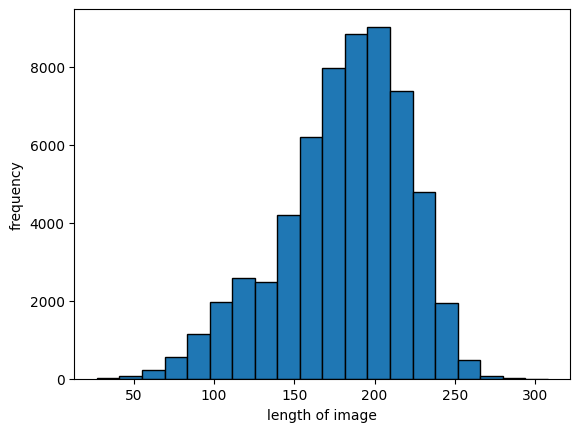

In [7]:
images_len = [len(i) for i in tokenized_images]
max_len = max(images_len)
min_len = min(images_len)
plt.axvline(x=max_len, color='r', linestyle='--', label=f'Max: {max_len}')
plt.axvline(x=min_len, color='g', linestyle='--', label=f'Min: {min_len}')
plt.hist(images_len, bins=20, edgecolor='black')
plt.xlabel('length of image')
plt.ylabel('frequency')
plt.show()

In [8]:
class MNISTDataset(Dataset):
    def __init__(self, images, labels, padding=False):
        self.images = images
        self.labels = labels
        self.padding = padding

        if self.padding:
            self.max_length = max(len(i) for i in self.images)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        attention_mask = None
        if self.padding:
            image, attention_mask = self.pad_image(image)
            attention_mask = torch.tensor(attention_mask, dtype=torch.int)
        image = torch.tensor(image, dtype=torch.int)
        label = torch.tensor(label, dtype=torch.long)
        return image, attention_mask, label
    
    def pad_image(self, image):
        max_len = self.max_length
        padded = np.pad(image, (0, max_len - len(image)))
        attention_mask = [1] * len(image) + [0] * (max_len - len(image))
        return padded, attention_mask

In [9]:
batch_size = 64

train_dataset = MNISTDataset(tokenized_images, labels, padding=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [17]:
model = AutoModel.from_pretrained('cardiffnlp/twitter-roberta-base-sentiment-latest')
model.to(device);

c:\Users\weiwe\anaconda3\envs\bpe\lib\site-packages\huggingface_hub\file_download.py:148: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\weiwe\.cache\huggingface\hub\models--cardiffnlp--twitter-roberta-base-sentiment-latest. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [18]:
embeddings = []
y_train = []

for images, attention_mask, labels in train_loader:
    images = images.to(device)
    attention_mask = attention_mask.to(device)
    with torch.no_grad():
        outputs = model(input_ids=images, attention_mask=attention_mask)
    
    last_hidden_states = outputs.last_hidden_state
    
    cls_embeddings = last_hidden_states[:, 0, :].detach().cpu().numpy()
    embeddings.append(cls_embeddings)
    y_train.append(labels.numpy())

In [19]:
X_train = np.concatenate(embeddings)
y_train = np.concatenate(y_train)

In [20]:
linear_model = LogisticRegression(solver='sag', max_iter=1000, multi_class='multinomial')
linear_model.fit(X_train, y_train)

c:\Users\weiwe\anaconda3\envs\bpe\lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\weiwe\anaconda3\envs\bpe\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', solver='sag')

In [21]:
linear_model.score(X_train, y_train)

0.6763